# Notebook 3: Exploratory Data Analysis

Visualisations:
- Time series plots with historical event annotations
- Distribution analysis
- Correlation heatmap
- ACF and PACF plots
- STL decomposition
- Rolling statistics

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from scipy import stats as scipy_stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})
COLORS = {'EPU': '#2563EB', 'CPU': '#16A34A', 'GPR': '#DC2626'}
print('Ready.')

Ready.


In [26]:
# Load data
df_raw  = pd.read_excel('../data/raw/POLICYUS.xlsx', parse_dates=['Date'], index_col='Date')
df_feat = pd.read_excel('../data/processed/filtered_data.xlsx')
df_feat.index = df_raw.index[:len(df_feat)]
print(f'Raw: {df_raw.shape} | Features: {df_feat.shape}')

Raw: (435, 140) | Features: (435, 62)


## 1. Time Series Plot with Event Annotations

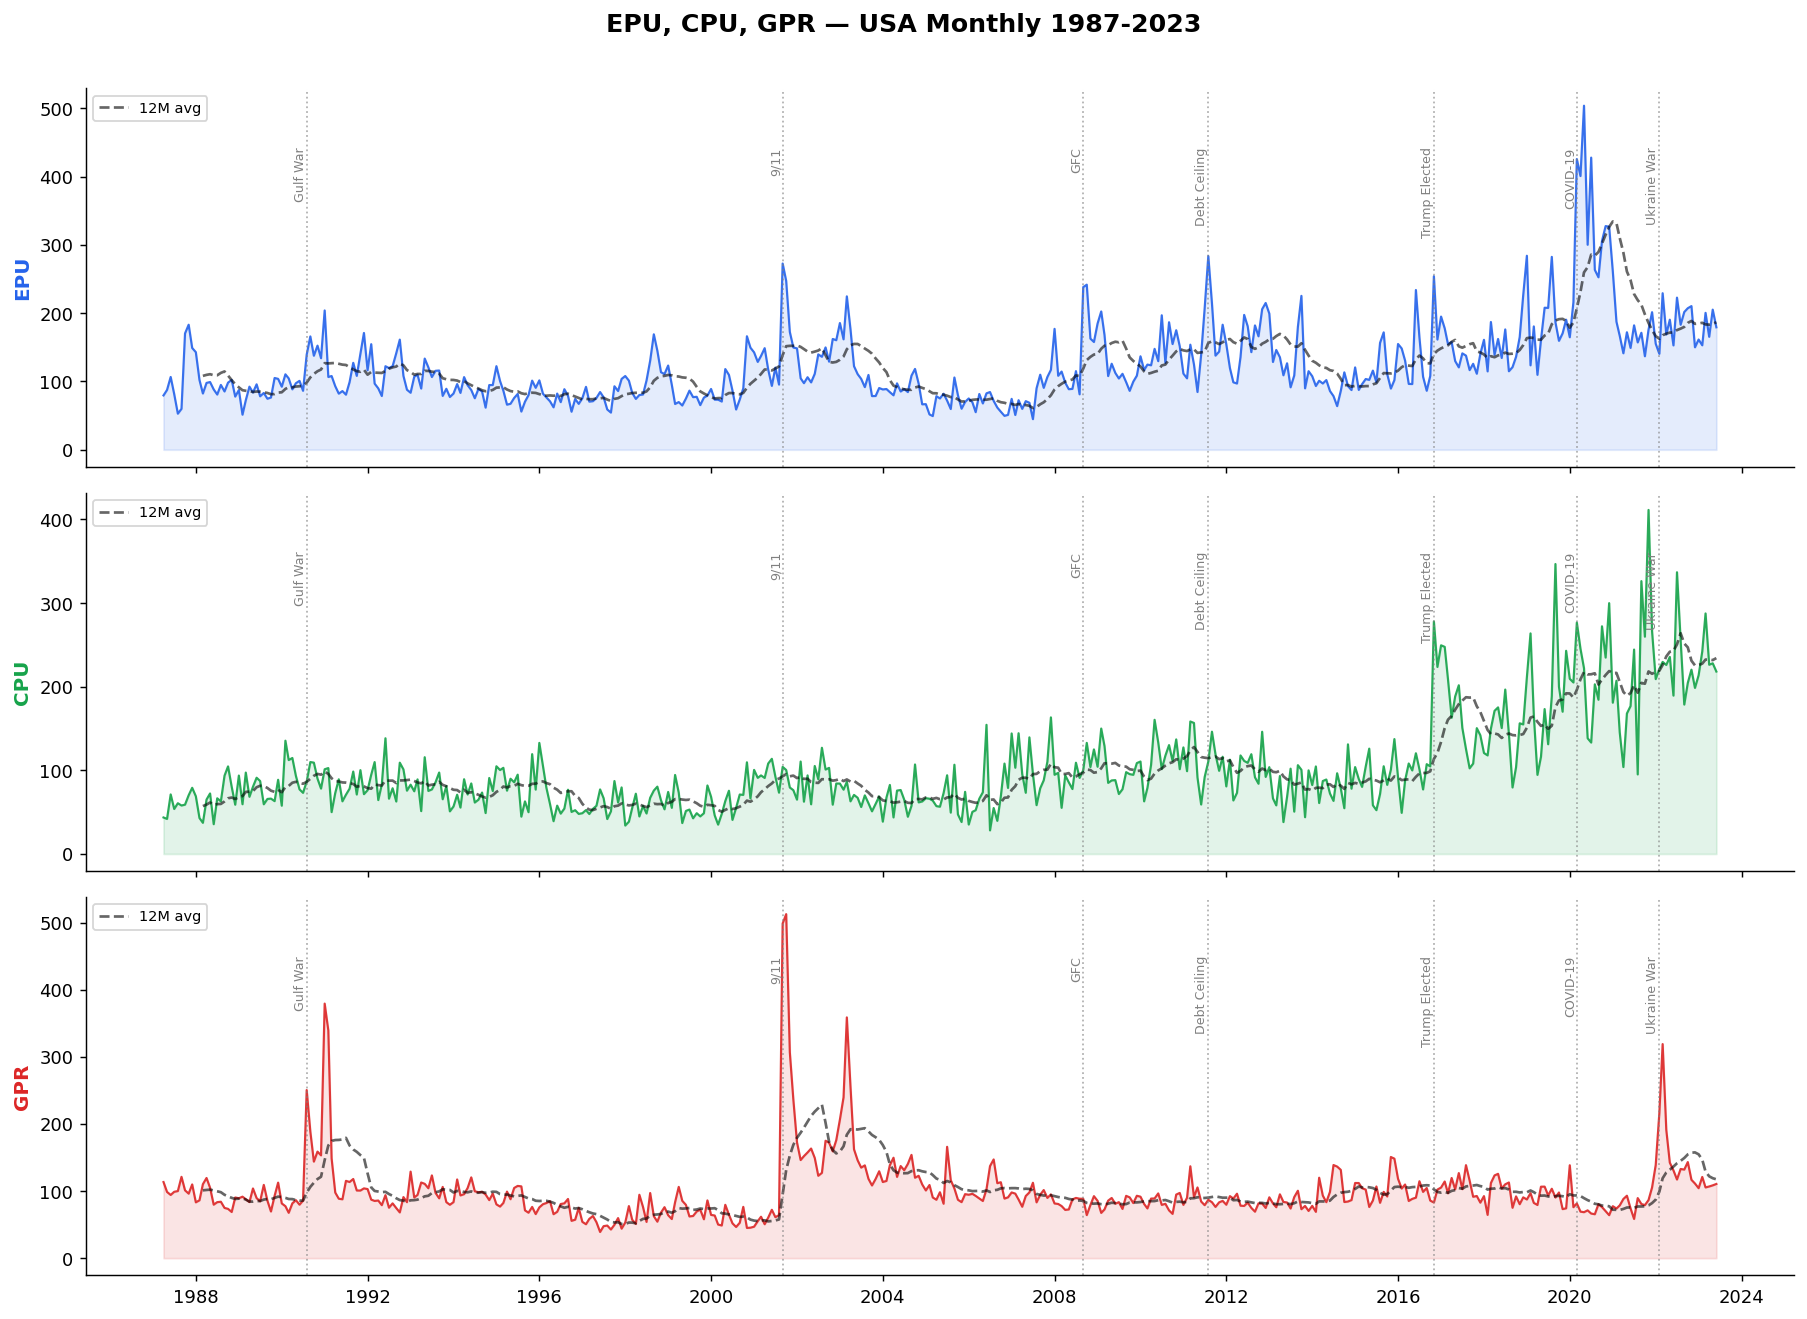

In [27]:
events = {
    '1990-08': 'Gulf War',
    '2001-09': '9/11',
    '2008-09': 'GFC',
    '2011-08': 'Debt Ceiling',
    '2016-11': 'Trump Elected',
    '2020-03': 'COVID-19',
    '2022-02': 'Ukraine War',
}

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for ax, col in zip(axes, ['EPU', 'CPU', 'GPR']):
    ax.plot(df_raw.index, df_raw[col], color=COLORS[col], linewidth=1.2, alpha=0.9)
    ax.fill_between(df_raw.index, df_raw[col], alpha=0.12, color=COLORS[col])
    rolling = df_raw[col].rolling(12).mean()
    ax.plot(df_raw.index, rolling, color='black', linewidth=1.5, linestyle='--', alpha=0.6, label='12M avg')
    for date_str, label in events.items():
        event_date = pd.Timestamp(date_str)
        ax.axvline(event_date, color='gray', linestyle=':', alpha=0.6, linewidth=1)
        ax.text(event_date, df_raw[col].max()*0.88, label, rotation=90,
                fontsize=7, va='top', ha='right', color='gray')
    ax.set_ylabel(col, fontsize=11, fontweight='bold', color=COLORS[col])
    ax.legend(fontsize=8, loc='upper left')

axes[-1].xaxis.set_major_locator(mdates.YearLocator(4))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.suptitle('EPU, CPU, GPR — USA Monthly 1987-2023', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/05_timeseries_annotated.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Distribution Analysis

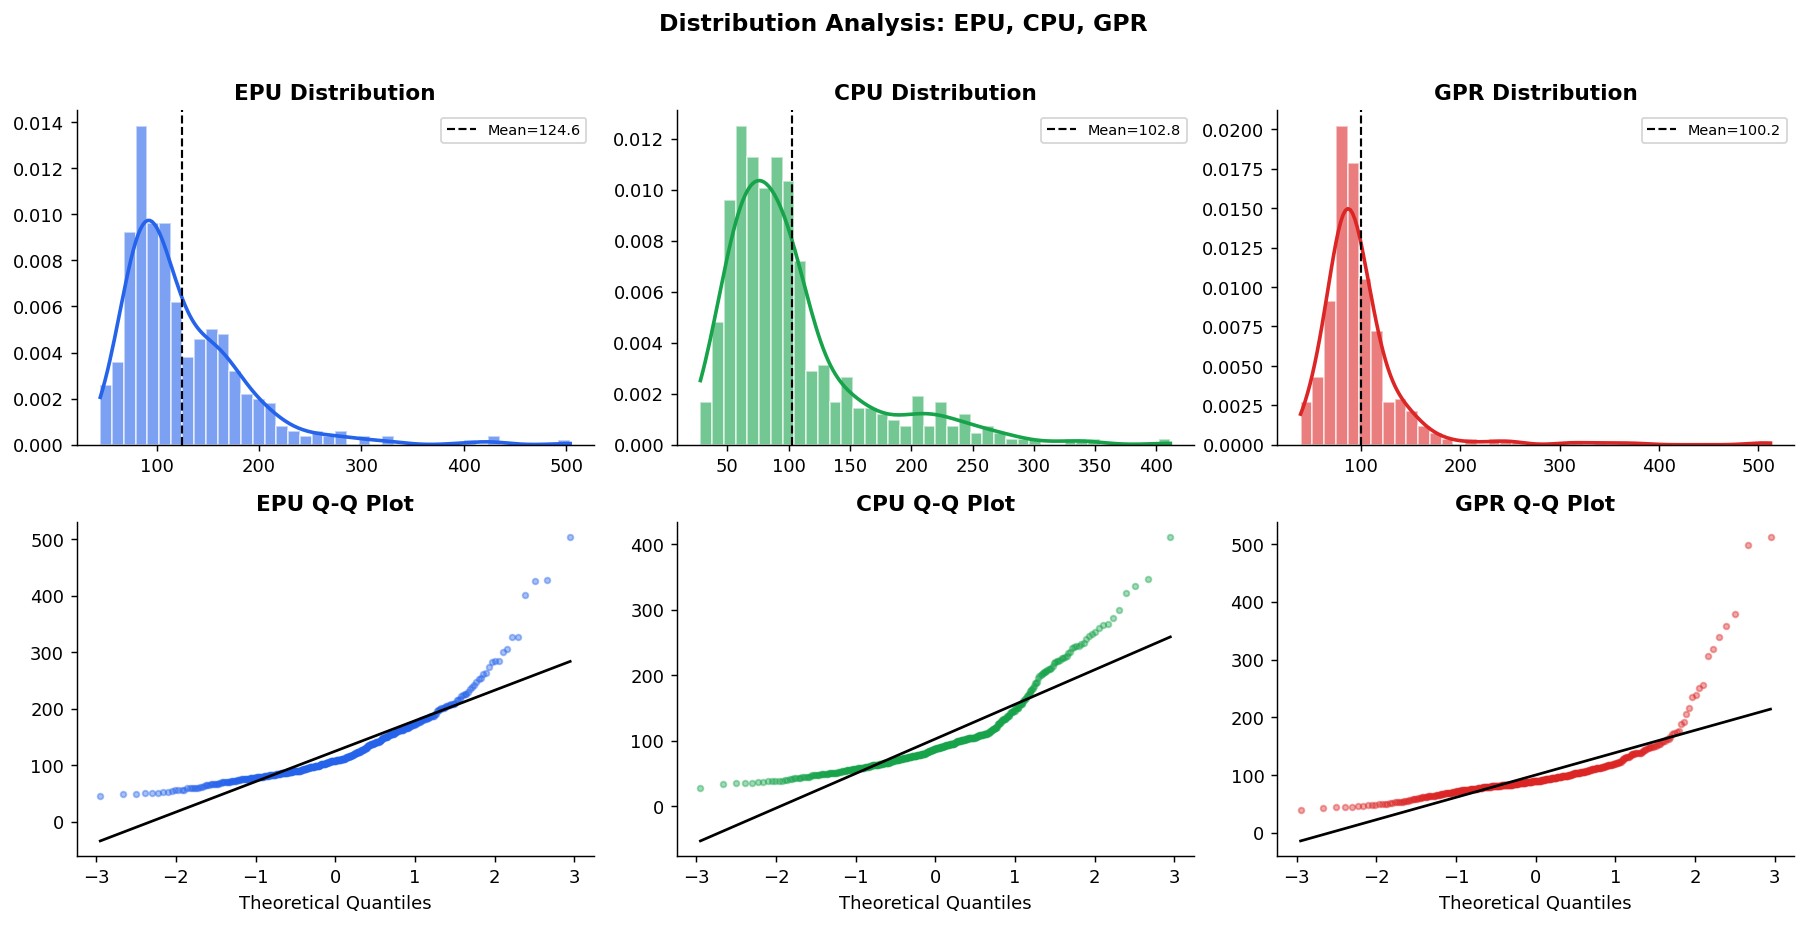

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for i, col in enumerate(['EPU', 'CPU', 'GPR']):
    series = df_raw[col].dropna()
    ax = axes[0, i]
    ax.hist(series, bins=40, color=COLORS[col], alpha=0.6, density=True, edgecolor='white')
    x_range = np.linspace(series.min(), series.max(), 200)
    kde = scipy_stats.gaussian_kde(series)
    ax.plot(x_range, kde(x_range), color=COLORS[col], linewidth=2)
    ax.axvline(series.mean(), color='black', linestyle='--', linewidth=1.2, label=f'Mean={series.mean():.1f}')
    ax.set_title(f'{col} Distribution', fontweight='bold')
    ax.legend(fontsize=8)

    ax = axes[1, i]
    (quantiles, values), (slope, intercept, r) = scipy_stats.probplot(series, dist='norm')
    ax.scatter(quantiles, values, color=COLORS[col], alpha=0.4, s=10)
    ax.plot(quantiles, slope*np.array(quantiles)+intercept, color='black', linewidth=1.5)
    ax.set_title(f'{col} Q-Q Plot', fontweight='bold')
    ax.set_xlabel('Theoretical Quantiles')

plt.suptitle('Distribution Analysis: EPU, CPU, GPR', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/06_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Correlation Heatmap

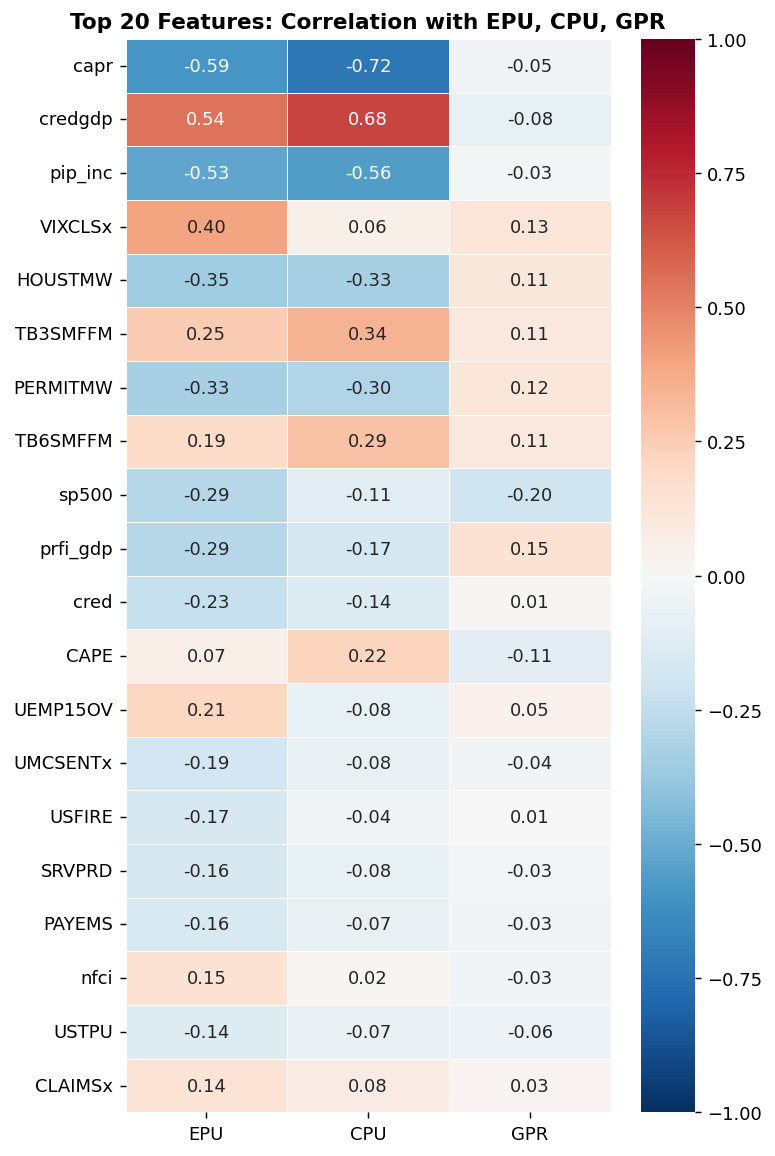

In [29]:
target_cols  = ['EPU', 'CPU', 'GPR']
feature_cols = [c for c in df_feat.columns if c not in target_cols + ['EPU.1']]
corr_matrix  = df_feat[target_cols + feature_cols].corr()[target_cols].drop(target_cols)
corr_matrix['max_abs'] = corr_matrix.abs().max(axis=1)
top_features = corr_matrix.nlargest(20, 'max_abs').drop(columns='max_abs')

fig, ax = plt.subplots(figsize=(6, 9))
sns.heatmap(top_features, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Top 20 Features: Correlation with EPU, CPU, GPR', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/07_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. ACF and PACF

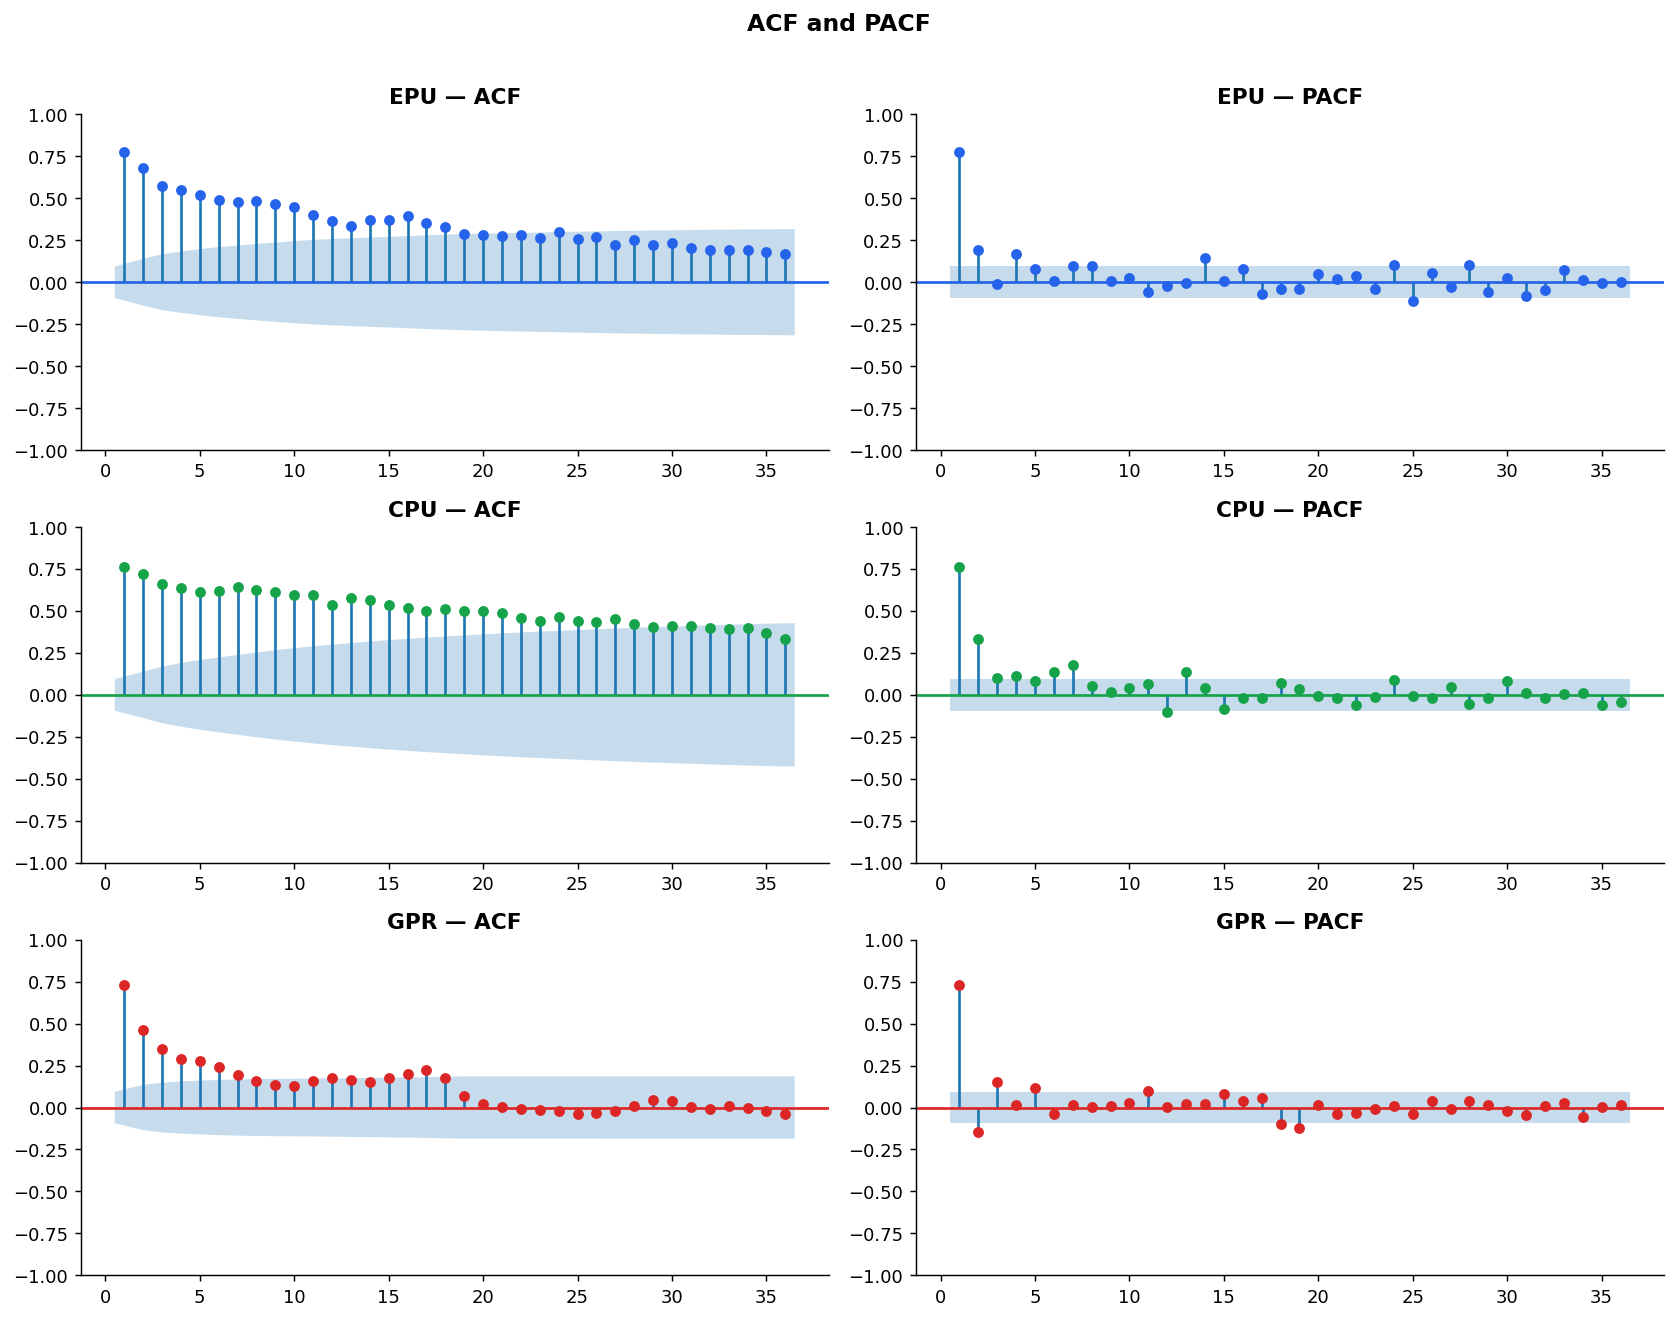

In [30]:
fig, axes = plt.subplots(3, 2, figsize=(13, 10))
for i, col in enumerate(['EPU', 'CPU', 'GPR']):
    series = df_raw[col].dropna()
    plot_acf(series, lags=36, ax=axes[i,0], alpha=0.05, color=COLORS[col], zero=False)
    axes[i,0].set_title(f'{col} — ACF', fontweight='bold')
    plot_pacf(series, lags=36, ax=axes[i,1], alpha=0.05, color=COLORS[col], zero=False, method='ywm')
    axes[i,1].set_title(f'{col} — PACF', fontweight='bold')
plt.suptitle('ACF and PACF', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/08_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. STL Decomposition

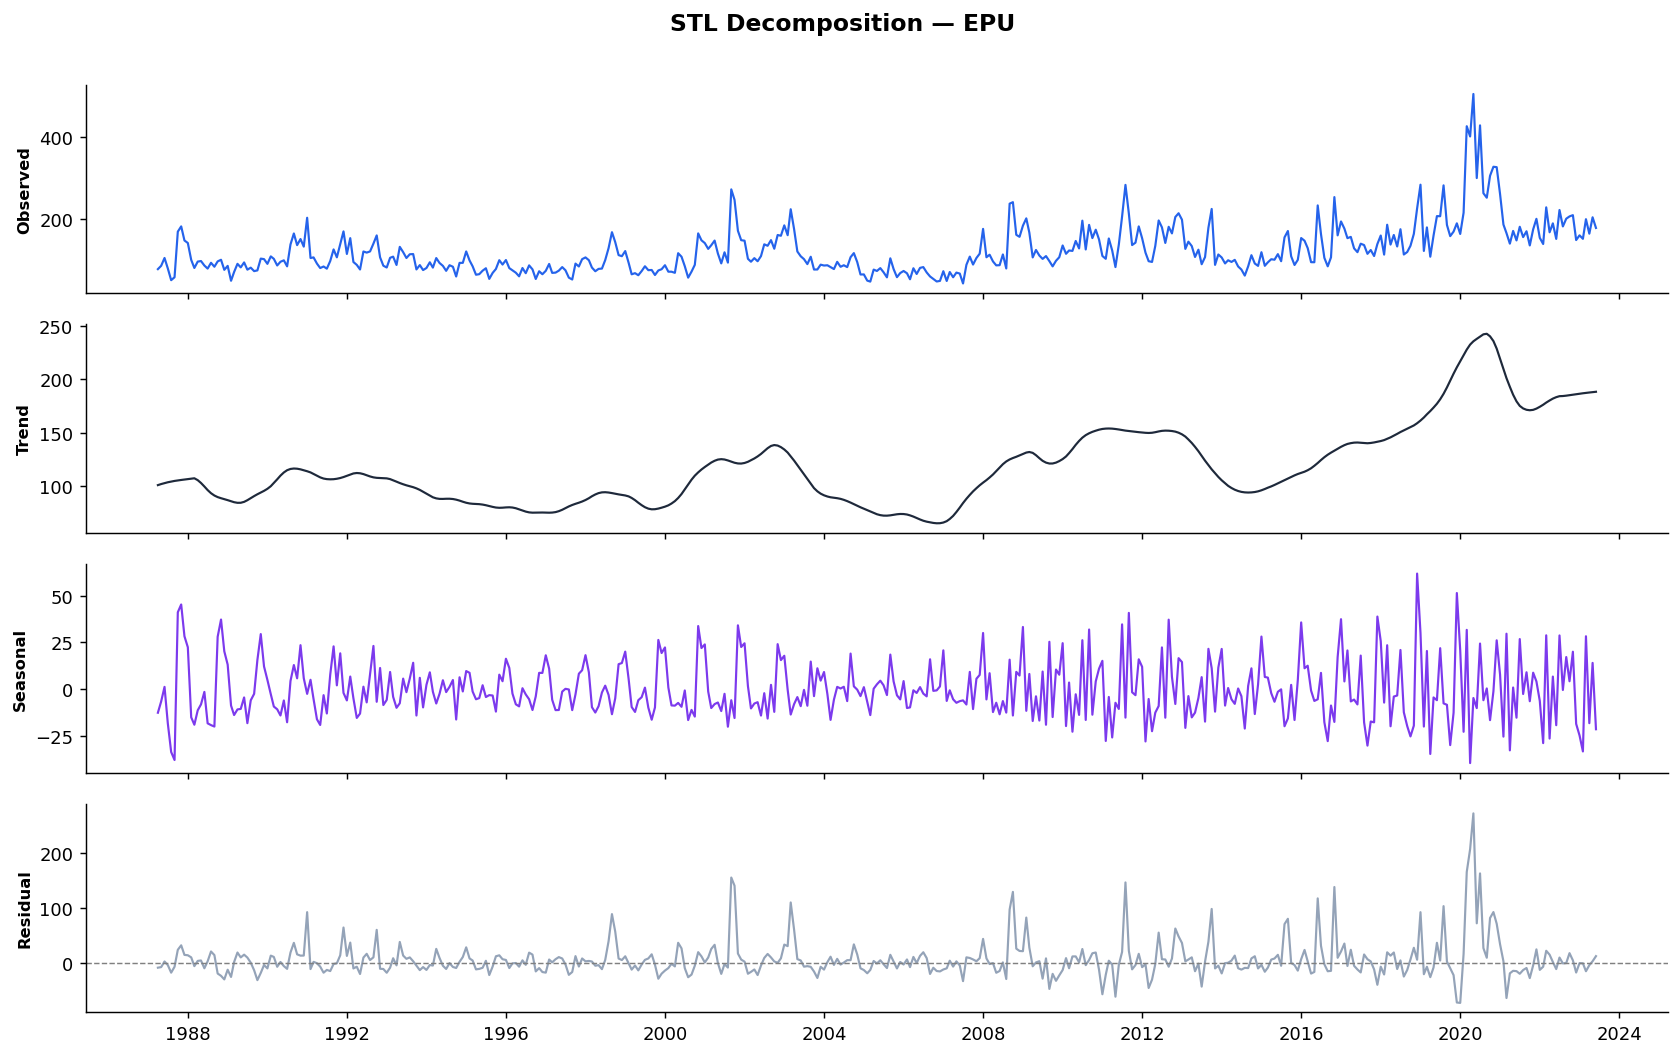

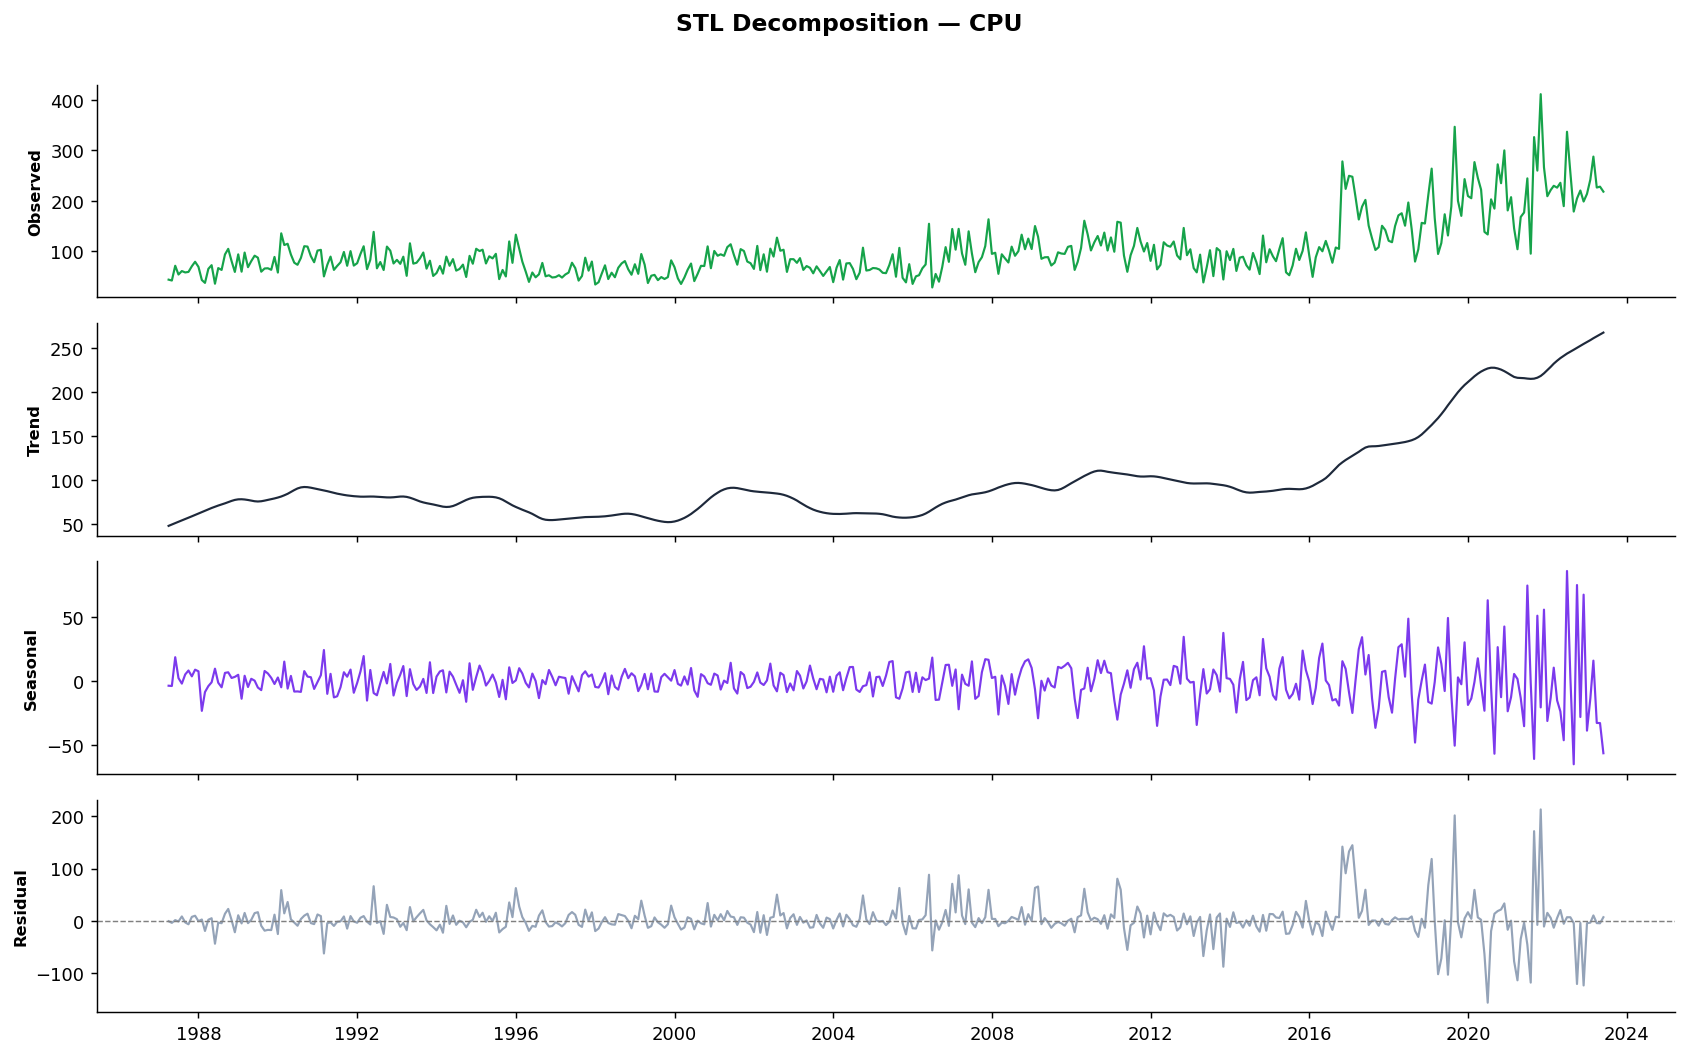

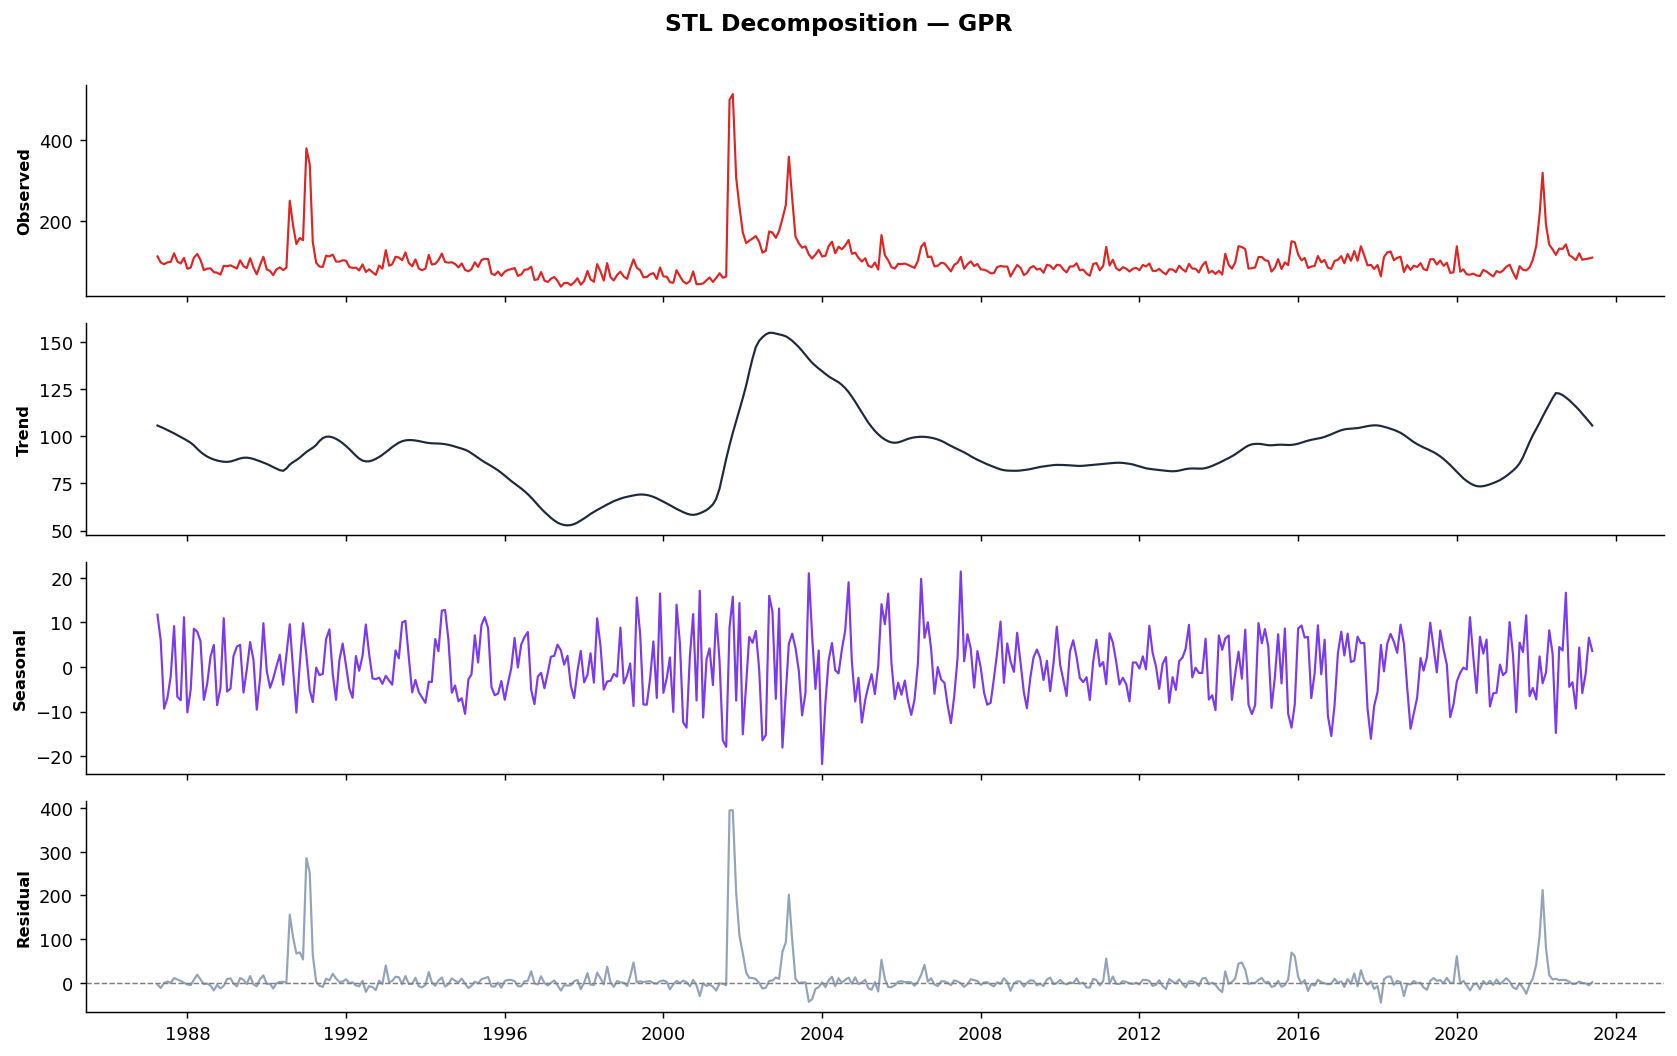

In [31]:
for col in ['EPU', 'CPU', 'GPR']:
    series = df_raw[col].dropna()
    stl    = STL(series, period=12, robust=True)
    result = stl.fit()
    fig, axes = plt.subplots(4, 1, figsize=(13, 8), sharex=True)
    for ax, (data, label, color) in zip(axes, [
        (series,        'Observed', COLORS[col]),
        (result.trend,  'Trend',    '#1E293B'),
        (result.seasonal,'Seasonal','#7C3AED'),
        (result.resid,  'Residual', '#94A3B8'),
    ]):
        ax.plot(data.index, data.values, color=color, linewidth=1.2)
        if label == 'Residual':
            ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
        ax.set_ylabel(label, fontsize=9, fontweight='bold')
    fig.suptitle(f'STL Decomposition — {col}', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'../outputs/09_stl_{col}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Rolling Statistics

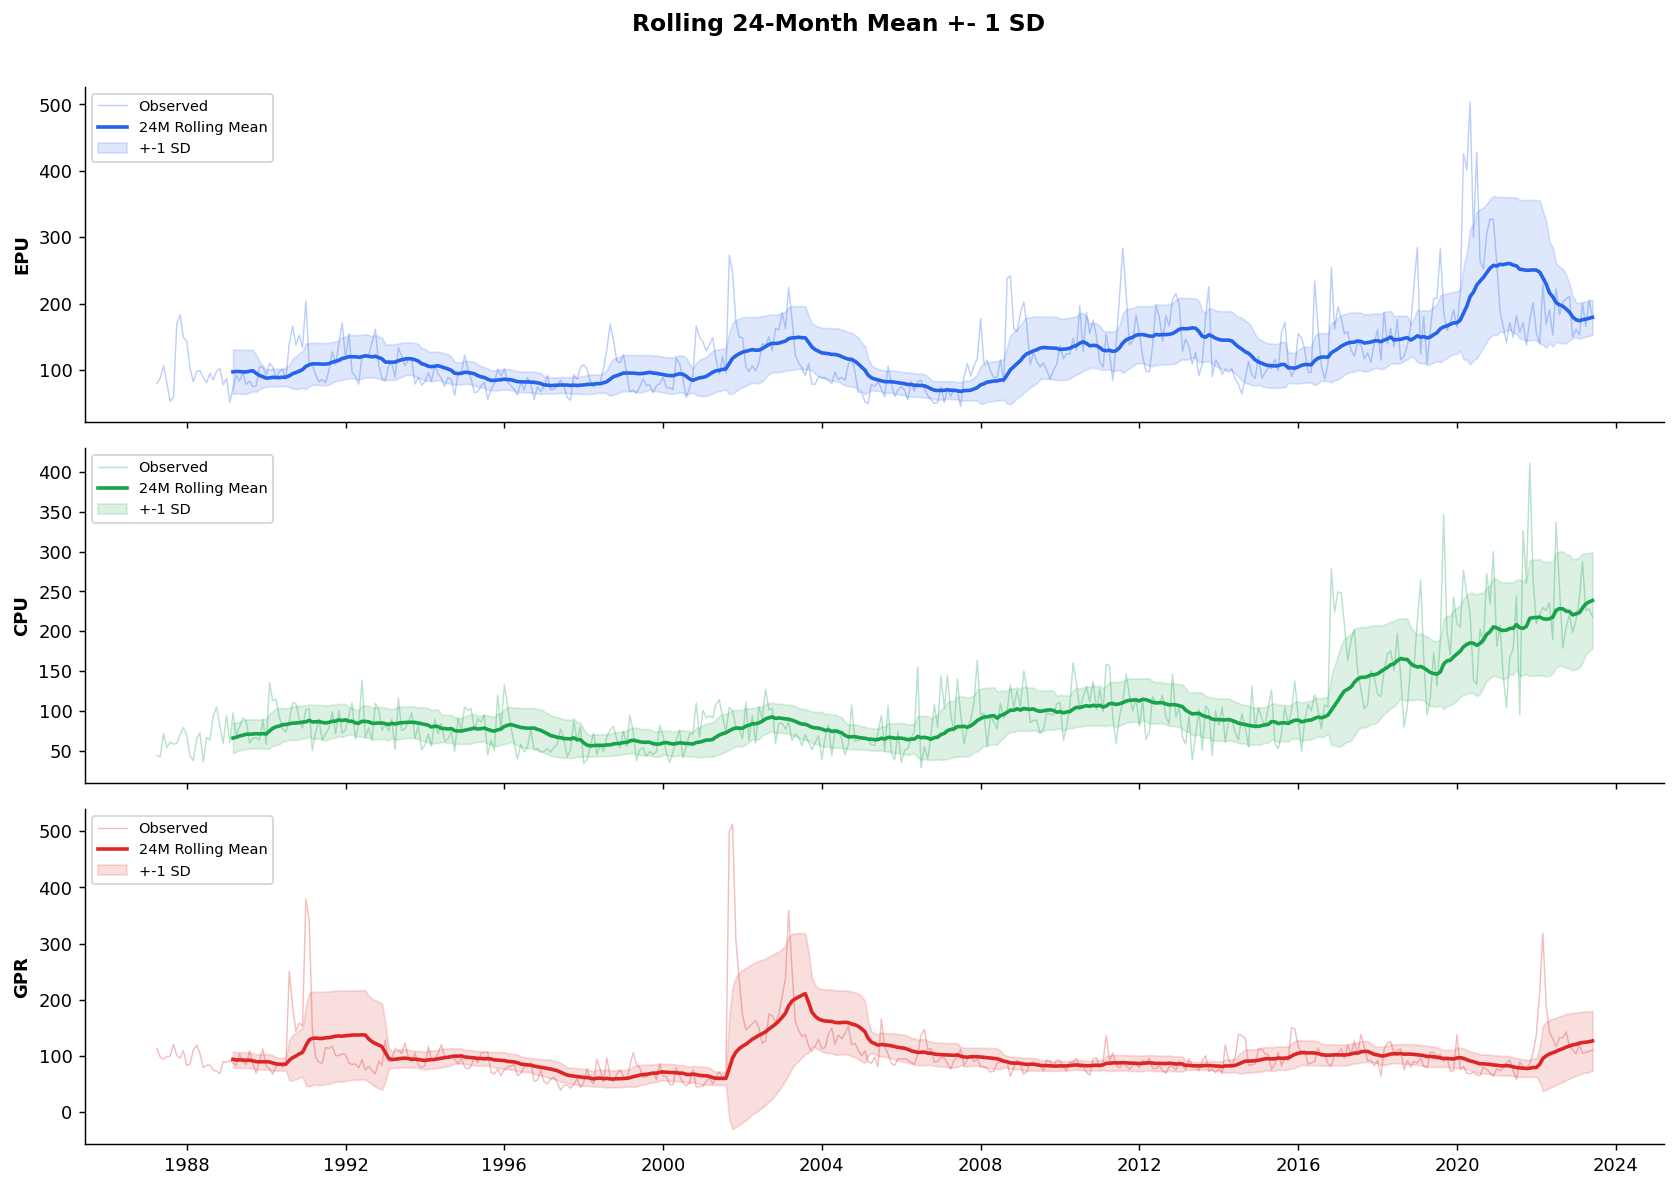

In [32]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for ax, col in zip(axes, ['EPU', 'CPU', 'GPR']):
    series    = df_raw[col].dropna()
    roll_mean = series.rolling(24).mean()
    roll_std  = series.rolling(24).std()
    ax.plot(series.index, series.values, color=COLORS[col], alpha=0.3, linewidth=0.8, label='Observed')
    ax.plot(roll_mean.index, roll_mean.values, color=COLORS[col], linewidth=2, label='24M Rolling Mean')
    ax.fill_between(series.index, roll_mean-roll_std, roll_mean+roll_std,
                    alpha=0.15, color=COLORS[col], label='+-1 SD')
    ax.set_ylabel(col, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
axes[-1].xaxis.set_major_locator(mdates.YearLocator(4))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.suptitle('Rolling 24-Month Mean +- 1 SD', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/10_rolling_stats.png', dpi=150, bbox_inches='tight')
plt.show()